In [1]:
import pandas as pd
import numpy as np

In [2]:
orders = pd.read_csv("blinkit_orders.csv")
order_items = pd.read_csv("blinkit_order_items.csv")
products = pd.read_csv("blinkit_products.csv")
customers = pd.read_csv("blinkit_customers.csv")

In [3]:
orders.head()

orders.info()

orders.shape

orders.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='object')

In [4]:
orders.describe()

,order_id,customer_id,order_total,delivery_partner_id,store_id
count,5.000000e+03,5.000000e+03,5000.00000,5000.000000,5000.000000
mean,5.029129e+09,5.009685e+07,2201.86170,50050.318200,4999.689000
std,2.863533e+09,2.919082e+07,1303.02438,28802.276922,2886.089242
min,6.046500e+04,3.181300e+04,13.25000,43.000000,1.000000
25%,2.531421e+09,2.404314e+07,1086.21500,24928.500000,2509.250000
50%,5.074378e+09,4.997808e+07,2100.69000,50262.500000,4987.000000
75%,7.488579e+09,7.621215e+07,3156.88250,74478.250000,7500.750000
max,9.998298e+09,9.989390e+07,6721.46000,99968.000000,9995.000000


In [5]:
orders.isnull().sum()

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

In [6]:
orders.describe(include='object')

,order_date,promised_delivery_time,actual_delivery_time,delivery_status,payment_method
count,5000,5000,5000,5000,5000
unique,5000,4999,5000,3,4
top,2024-07-17 08:34:01,2024-10-13 14:06:50,2024-07-17 08:47:01,On Time,Card
freq,1,2,1,3470,1285


In [7]:
orders.nunique()

order_id                  5000
customer_id               2172
order_date                5000
promised_delivery_time    4999
actual_delivery_time      5000
delivery_status              3
order_total               4550
payment_method               4
delivery_partner_id       5000
store_id                  5000
dtype: int64

In [8]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

In [9]:
orders.dtypes

order_id                           int64
customer_id                        int64
order_date                datetime64[ns]
promised_delivery_time    datetime64[ns]
actual_delivery_time      datetime64[ns]
delivery_status                   object
order_total                      float64
payment_method                    object
delivery_partner_id                int64
store_id                           int64
dtype: object

In [10]:
orders['delivery_time_minutes'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

In [11]:
orders[['order_date',
        'actual_delivery_time',
        'delivery_time_minutes']].head()

,order_date,actual_delivery_time,delivery_time_minutes
0,2024-07-17 08:34:01,2024-07-17 08:47:01,13.0
1,2024-05-28 13:14:29,2024-05-28 13:27:29,13.0
2,2024-09-23 13:07:12,2024-09-23 13:29:12,22.0
3,2023-11-24 16:16:56,2023-11-24 16:33:56,17.0
4,2023-11-20 05:00:39,2023-11-20 05:18:39,18.0


In [14]:
import matplotlib.pyplot as plt

In [15]:
#Payment Method Analysis
orders['payment_method'].value_counts()

payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64

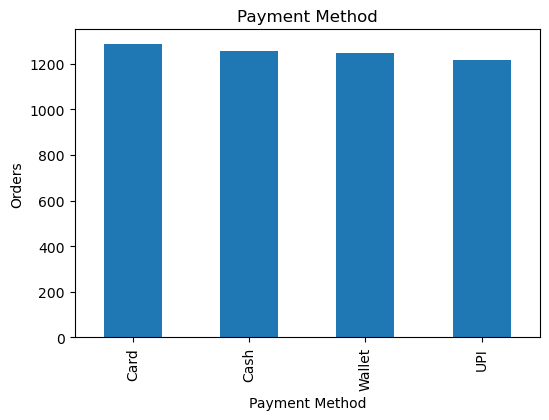

In [16]:
orders['payment_method'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Orders')
plt.show()

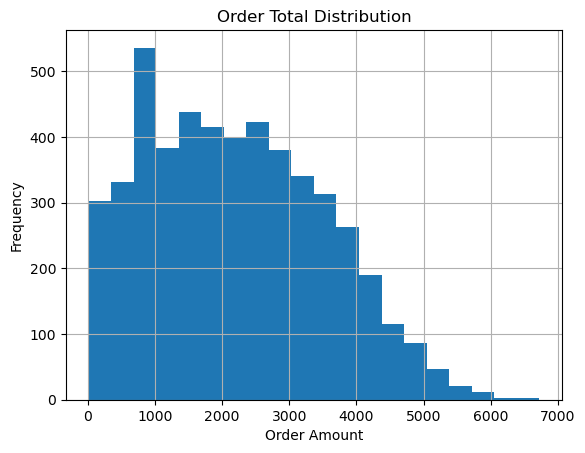

In [17]:
#Order Total Distribution
orders['order_total'].hist(bins=20)
plt.title("Order Total Distribution")
plt.xlabel("Order Amount")
plt.ylabel("Frequency")
plt.show()

In [18]:
#Average Delivery Time
orders['delivery_time_minutes'].describe()

count    5000.000000
mean       19.434400
std         8.659486
min         5.000000
25%        13.000000
50%        18.000000
75%        24.000000
max        50.000000
Name: delivery_time_minutes, dtype: float64

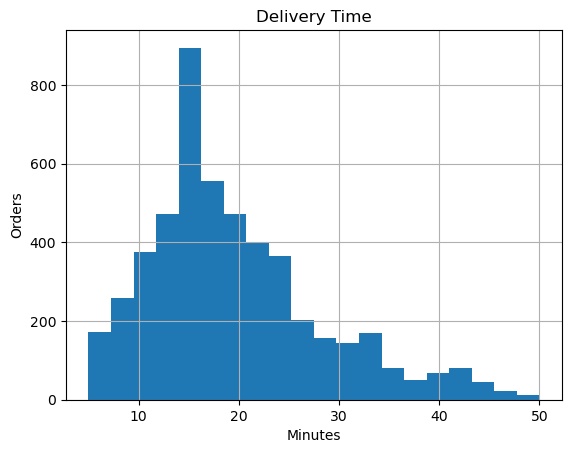

In [19]:
orders['delivery_time_minutes'].hist(bins=20)
plt.title("Delivery Time")
plt.xlabel("Minutes")
plt.ylabel("Orders")
plt.show()

In [20]:
#Monthly Orders Trend
orders['Month'] = orders['order_date'].dt.to_period('M')

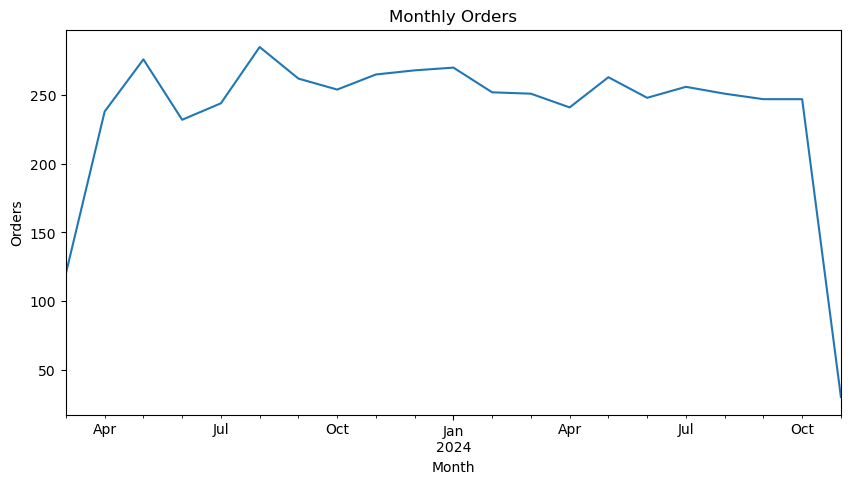

In [23]:
monthly_orders = orders.groupby('Month').size()
monthly_orders.plot(figsize=(10,5))
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

#customer , product, order_item table analyze

In [25]:
customers.head()
customers.info()
customers.isnull().sum()
customers.duplicated().sum()
customers.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   object 
 2   email              2500 non-null   object 
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   object 
 5   area               2500 non-null   object 
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   object 
 8   customer_segment   2500 non-null   object 
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 215.0+ KB


,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
count,2.500000e+03,2500,2500,2.500000e+03,2500,2500,2500.000000,2500,2500,2500.000000,2500.000000
unique,NaN,2491,2496,NaN,2500,316,NaN,589,4,NaN,NaN
top,NaN,Isaac Rattan,wvora@example.org,NaN,"23, Nayar Path, Bihar Sharif-154625",Jalna,NaN,2024-03-18,Regular,NaN,NaN
freq,NaN,2,2,NaN,1,18,NaN,10,639,NaN,NaN
mean,4.989961e+07,NaN,NaN,9.150532e+11,NaN,NaN,497653.183200,NaN,NaN,10.491600,1102.375836
std,2.919266e+07,NaN,NaN,2.882835e+09,NaN,NaN,281167.293249,NaN,NaN,5.805533,523.043183
min,3.181300e+04,NaN,NaN,9.100132e+11,NaN,NaN,666.000000,NaN,NaN,1.000000,200.430000
25%,2.402443e+07,NaN,NaN,9.125946e+11,NaN,NaN,257079.750000,NaN,NaN,6.000000,631.817500
50%,5.000044e+07,NaN,NaN,9.150236e+11,NaN,NaN,498662.000000,NaN,NaN,10.000000,1118.650000
75%,7.595459e+07,NaN,NaN,9.176256e+11,NaN,NaN,740668.000000,NaN,NaN,16.000000,1565.400000


In [26]:
products.head()
products.info()
products.isnull().sum()
products.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         268 non-null    int64  
 1   product_name       268 non-null    object 
 2   category           268 non-null    object 
 3   brand              268 non-null    object 
 4   price              268 non-null    float64
 5   mrp                268 non-null    float64
 6   margin_percentage  268 non-null    float64
 7   shelf_life_days    268 non-null    int64  
 8   min_stock_level    268 non-null    int64  
 9   max_stock_level    268 non-null    int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 21.1+ KB


,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
count,268.000000,268,268,268,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
unique,NaN,51,11,267,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Pet Treats,Dairy & Breakfast,Jha Group,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,30,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,514855.940299,NaN,NaN,NaN,488.356828,680.434739,27.779851,231.757463,20.388060,74.753731
std,291391.529820,NaN,NaN,NaN,298.487200,419.772224,7.458753,151.205830,5.958546,14.591535
min,4452.000000,NaN,NaN,NaN,12.320000,17.600000,15.000000,3.000000,10.000000,50.000000
25%,273697.750000,NaN,NaN,NaN,226.717500,325.150000,20.000000,90.000000,15.000000,63.750000
50%,541459.000000,NaN,NaN,NaN,442.185000,616.970000,30.000000,365.000000,21.000000,73.000000
75%,754334.000000,NaN,NaN,NaN,779.445000,1056.620000,35.000000,365.000000,25.250000,88.000000


In [27]:
order_items.head()
order_items.info()
order_items.isnull().sum()
order_items.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    5000 non-null   int64  
 1   product_id  5000 non-null   int64  
 2   quantity    5000 non-null   int64  
 3   unit_price  5000 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 156.4 KB


,order_id,product_id,quantity,unit_price
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,5.029129e+09,509974.939600,2.006800,493.157900
std,2.863533e+09,293678.307475,0.820542,298.075647
min,6.046500e+04,4452.000000,1.000000,12.320000
25%,2.531421e+09,257719.000000,1.000000,227.220000
50%,5.074378e+09,540618.000000,2.000000,448.160000
75%,7.488579e+09,747801.000000,3.000000,781.080000
max,9.998298e+09,993331.000000,3.000000,995.980000


In [28]:
orders.columns
customers.columns
products.columns
order_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='object')

In [29]:
orders_customers = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)

In [30]:
orders_customers.head()
orders_customers.shape

(5000, 22)

In [31]:
orders_items = pd.merge(
    orders_customers,
    order_items,
    on='order_id',
    how='left'
)

orders_items.head()
orders_items.shape

(5000, 25)

In [32]:
master_data = pd.merge(
    orders_items,
    products,
    on='product_id',
    how='left'
)
master_data.head()
master_data.shape

(5000, 34)

In [33]:
master_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                5000 non-null   int64         
 1   customer_id             5000 non-null   int64         
 2   order_date              5000 non-null   datetime64[ns]
 3   promised_delivery_time  5000 non-null   datetime64[ns]
 4   actual_delivery_time    5000 non-null   datetime64[ns]
 5   delivery_status         5000 non-null   object        
 6   order_total             5000 non-null   float64       
 7   payment_method          5000 non-null   object        
 8   delivery_partner_id     5000 non-null   int64         
 9   store_id                5000 non-null   int64         
 10  delivery_time_minutes   5000 non-null   float64       
 11  Month                   5000 non-null   period[M]     
 12  customer_name           5000 non-null   object  

In [34]:
master_data['order_total'].sum()

np.float64(11009308.5)

In [35]:
master_data['order_id'].nunique()

5000

In [36]:
master_data['customer_id'].nunique()

2172

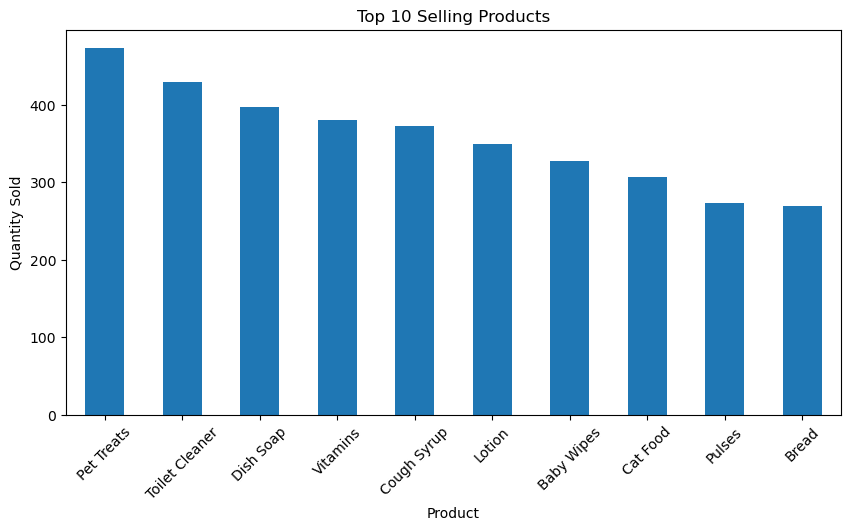

In [40]:
top_products = master_data.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

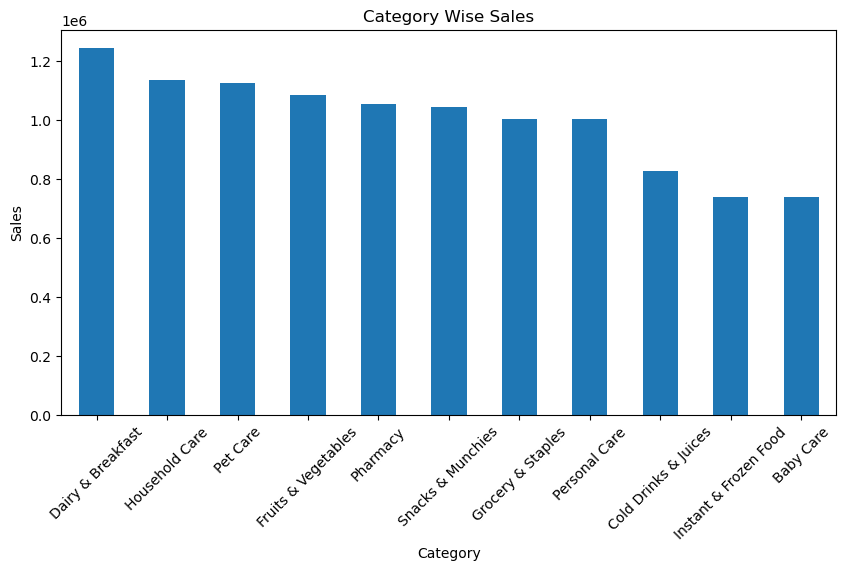

In [41]:
category_sales = master_data.groupby('category')['order_total'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', figsize=(10,5))
plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

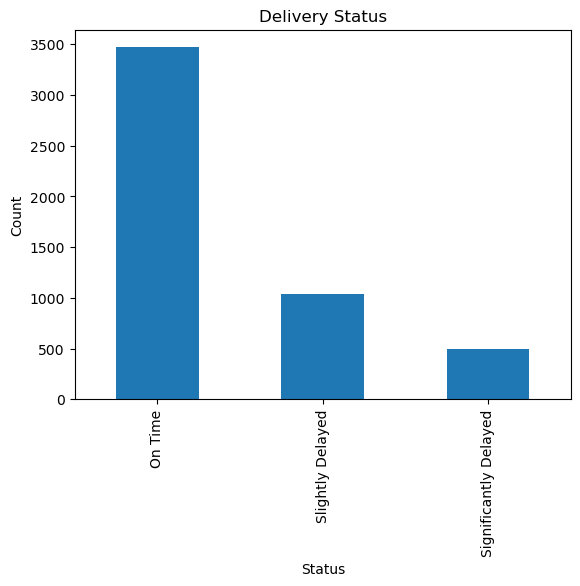

In [42]:
master_data['delivery_status'].value_counts().plot(kind='bar')
plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

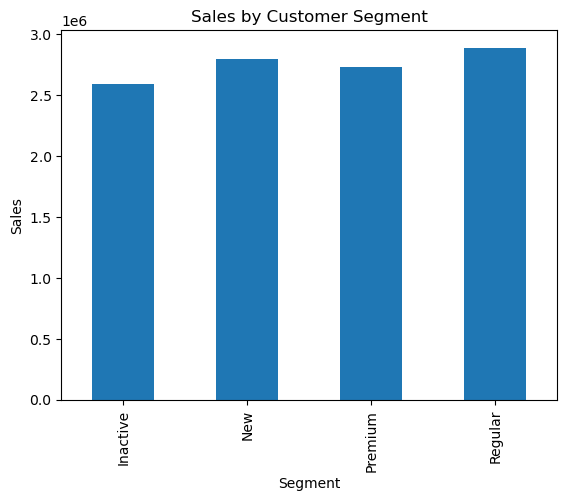

In [43]:
segment_sales = master_data.groupby('customer_segment')['order_total'].sum()

segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()